### Astrostatistics lecure 5

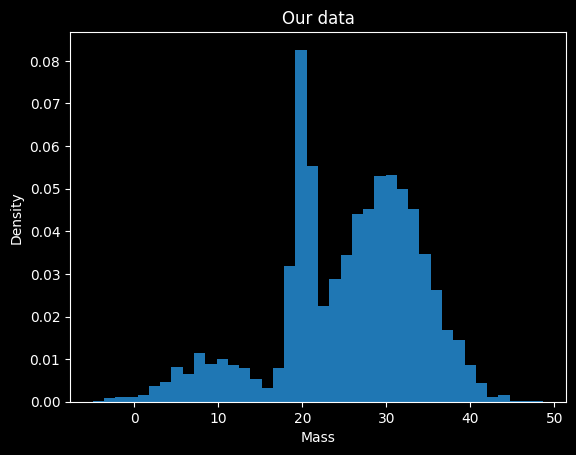

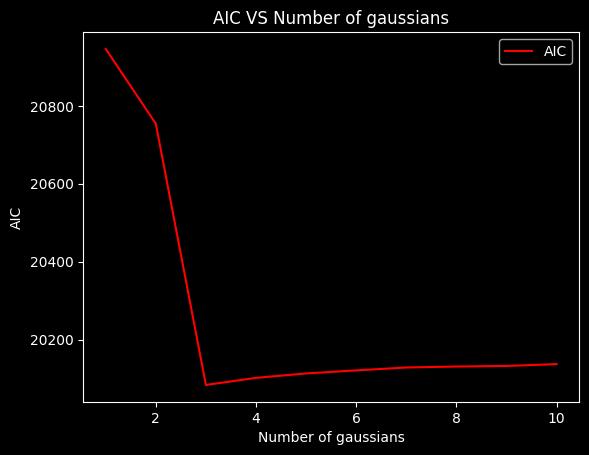

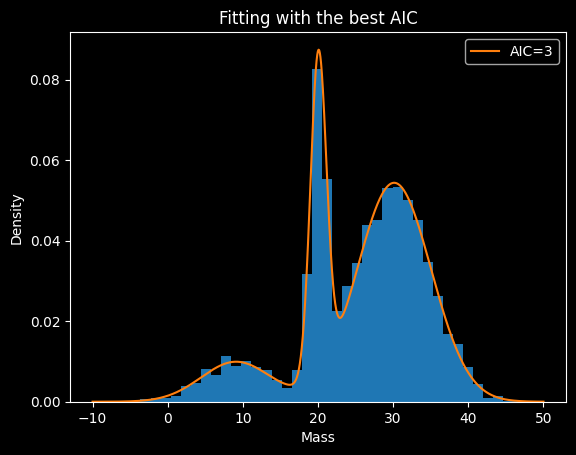

In [63]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.mixture import GaussianMixture 
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

data = np.load("/home/ricca/astrostat/astrostatistics_bicocca_2026/solutions/formationchannels.npy") #load data

plt.title('Our data') #plot data 
plt.hist(data, bins=40, density=True)
plt.ylabel('Density')
plt.xlabel('Mass')
plt.show()
AIC=[]
num=[]

for i in range(10): #initialize our model with our data 
    gauss_mix = GaussianMixture(n_components=i+1, random_state=42).fit(data) #mixture of 10 gaussians 
    AIC.append(gauss_mix.aic(data)) #take the AIC values 
    num.append(i+1)
index=np.argmin(AIC)+1 #find the best AIC (the +1 is because the array starts at 0, while the gaussians at 1)

plt.plot(num, AIC, color='red', label = 'AIC') #dependence of the AIC as funcion of the number of gaussians
plt.ylabel('AIC')
plt.xlabel('Number of gaussians')
plt.legend()
plt.title('AIC VS Number of gaussians')
plt.show()

#fit with the best AIC
best_mix = GaussianMixture(n_components=index, random_state=42).fit(data)
x=np.linspace(-10, 50, 5000).reshape(-1,1) #reshape needed to match the type (-1,1)
log_likeli = best_mix.score_samples(x)
likeli = np.exp (log_likeli)

plt.hist(data, bins=40, density=True) #plot the best fit
plt.title('Fitting with the best AIC')
plt.plot(x, likeli, label=f'AIC={index}')
plt.legend()
plt.ylabel('Density')
plt.xlabel('Mass')
plt.show()


#### Optional section

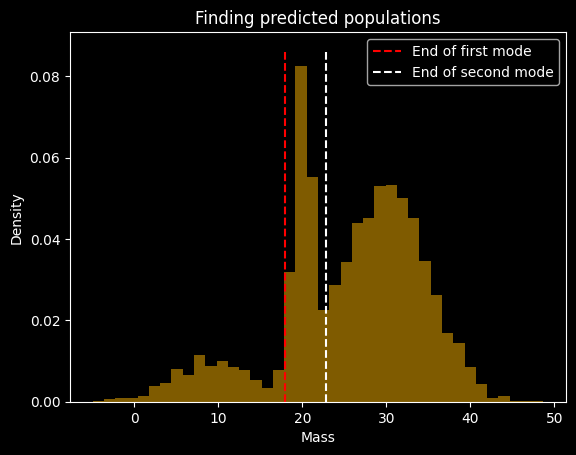

In [64]:
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'   #custom plot stuff

popul = best_mix.predict_proba(x)   #use the prediction to fund the most probable population for the data 
pop = []

for i in range(len(popul)):
    pop.append(np.argmax(popul[i])) #find the place (0,1,2) where the probability density is maximum 

pop0=pop.count(0)   #count for each 
pop1=pop.count(1)
pop2=pop.count(2)
hist, bin_edges = np.histogram(data, bins=50, density=True)
maxim = np.argmax(hist)
height = hist[maxim] #maximum height of the histogram

#plot the limits of the modes in the data
plt.vlines(x[pop0], 0, height, label='End of first mode', linestyle='dashed', color='red') #x[pop0] takes care of the rescaling done before 
plt.vlines(x[pop0+pop1], 0, height, label='End of second mode', linestyle = 'dashed', color='white')
plt.hist(data, bins=40, density=True, alpha=0.5, color="#FFB700")
plt.legend()
plt.title('Finding predicted populations')
plt.ylabel('Density')
plt.xlabel('Mass')
plt.show()
